In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("gasolina_limpa.csv")
petroleo = pd.read_csv("petroleo_tratado.csv")

In [3]:
df.head()

,Unnamed: 0,Produto,Data da Coleta,Valor de Venda,Unidade de Medida
0,0,GASOLINA,11/05/2004,1.967,R$ / litro
1,3,GASOLINA,10/05/2004,1.850,R$ / litro
2,6,GASOLINA,10/05/2004,2.030,R$ / litro
3,9,GASOLINA,11/05/2004,1.910,R$ / litro
4,12,GASOLINA,10/05/2004,2.039,R$ / litro


In [4]:
# Vamos usar a biblioteca yfinance pois ela contem o valor do cambio ao longo do tempo
!pip install yfinance

In [5]:
petroleo.head()


,Unnamed: 0,date,price,percentChange,change
0,1,01/04/1983,30.63,4.646,1.36
1,2,01/05/1983,30.25,-1.241,-0.38
2,3,01/06/1983,31.38,3.736,1.13
3,4,01/07/1983,32.00,1.976,0.62
4,5,01/08/1983,31.59,-1.281,-0.41


In [6]:
#Arruamos a data para conseguir relacionar com o cambio
petroleo["date"] = pd.to_datetime(petroleo["date"], dayfirst=True)

In [7]:
petroleo = petroleo[petroleo["date"] >= "2005-01-01"]

In [8]:
petroleo.head()

,Unnamed: 0,date,price,percentChange,change
261,262,2005-01-01,48.20,10.932,4.75
262,263,2005-02-01,51.75,7.365,3.55
263,264,2005-03-01,55.40,7.053,3.65
264,265,2005-04-01,49.72,-10.253,-5.68
265,266,2005-05-01,51.97,4.525,2.25


In [9]:
import yfinance as yf

In [10]:
#Da bibliotexa yfinance baixamos os valores do cambio do real
fx = yf.download("BRL=X", start="2005-01-01")

[*********************100%***********************]  1 of 1 completed


In [11]:
fx = fx["Close"].reset_index()

In [12]:
#Mudamos os nomes de algumas colunas
fx.rename(columns={
    "Date": "date",
    "Close": "cambio"
}, inplace=True)

In [13]:

petroleo["date"] = pd.to_datetime(petroleo["date"])
fx["date"] = pd.to_datetime(fx["date"])

In [14]:
petroleo = petroleo.sort_values("date")
fx = fx.sort_values("date")

In [15]:
petroleo["date"] = pd.to_datetime(petroleo["date"]).astype("datetime64[ns]")
fx["date"] = pd.to_datetime(fx["date"]).astype("datetime64[ns]")

In [16]:

print(petroleo["date"].dtype)
print(fx["date"].dtype)

datetime64[ns]
datetime64[ns]


In [17]:
petroleo = pd.merge_asof(
    petroleo,
    fx.sort_values("date"),
    on="date"
)

In [18]:
petroleo.head()

,Unnamed: 0,date,price,percentChange,change,BRL=X
0,262,2005-01-01,48.20,10.932,4.75,NaN
1,263,2005-02-01,51.75,7.365,3.55,NaN
2,264,2005-03-01,55.40,7.053,3.65,NaN
3,265,2005-04-01,49.72,-10.253,-5.68,NaN
4,266,2005-05-01,51.97,4.525,2.25,NaN


In [19]:

petroleo = petroleo.rename(columns={"BRL=X": "cambio"})

In [20]:
petroleo.head()

,Unnamed: 0,date,price,percentChange,change,cambio
0,262,2005-01-01,48.20,10.932,4.75,NaN
1,263,2005-02-01,51.75,7.365,3.55,NaN
2,264,2005-03-01,55.40,7.053,3.65,NaN
3,265,2005-04-01,49.72,-10.253,-5.68,NaN
4,266,2005-05-01,51.97,4.525,2.25,NaN


In [21]:
petroleo["cambio"].isna().sum()

np.int64(15)

In [22]:
#Adicionamos o valor do cambio
petroleo = petroleo.sort_values("date")
petroleo["cambio"] = petroleo["cambio"].ffill().bfill()

In [23]:
petroleo.head()

,Unnamed: 0,date,price,percentChange,change,cambio
0,262,2005-01-01,48.20,10.932,4.75,2.1672
1,263,2005-02-01,51.75,7.365,3.55,2.1672
2,264,2005-03-01,55.40,7.053,3.65,2.1672
3,265,2005-04-01,49.72,-10.253,-5.68,2.1672
4,266,2005-05-01,51.97,4.525,2.25,2.1672


In [24]:
petroleo.tail()

,Unnamed: 0,date,price,percentChange,change,cambio
250,512,2025-11-01,58.5500,-3.985,-2.4300,5.3820
251,513,2025-12-01,57.4200,-1.930,-1.1300,5.3354
252,514,2026-01-01,65.2100,13.567,7.7900,5.4762
253,515,2026-02-01,67.0200,2.776,1.8100,5.1892
254,516,2026-03-01,91.4155,36.400,24.3955,5.1366


In [25]:
petroleo["preco"] = petroleo["price"] * petroleo["cambio"];

In [26]:
petroleo.tail()

,Unnamed: 0,date,price,percentChange,change,cambio,preco
250,512,2025-11-01,58.5500,-3.985,-2.4300,5.3820,315.116098
251,513,2025-12-01,57.4200,-1.930,-1.1300,5.3354,306.358674
252,514,2026-01-01,65.2100,13.567,7.7900,5.4762,357.103009
253,515,2026-02-01,67.0200,2.776,1.8100,5.1892,347.780179
254,516,2026-03-01,91.4155,36.400,24.3955,5.1366,469.564859


In [27]:
petroleo.to_csv("petroleo_cambio.csv")

In [28]:
!pip install matplotlib seaborn

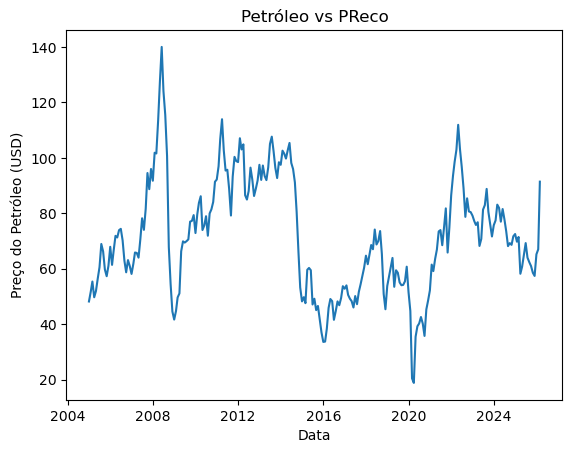

In [29]:
#Fizemos um gráfico do valor do petroleo ao longo dos anos
import matplotlib.pyplot as plt

plt.plot(petroleo["date"], petroleo["price"])
plt.xlabel("Data")
plt.ylabel("Preço do Petróleo (USD)")
plt.title("Petróleo vs PReco")

plt.show()